In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold

In [4]:
# Load data
train_df = pd.read_csv("/content/BT2024087_train_var2.csv")
test_df = pd.read_csv("/content/BT2024087_test_var2.csv")

print("Training shape:", train_df.shape)
print("Test shape:", test_df.shape)

print("\nTraining columns:", train_df.columns.tolist())
print("Test columns:", test_df.columns.tolist())

train_df.head()

Training shape: (1000, 4)
Test shape: (1000, 3)

Training columns: ['x1', 'x2', 'x3', 'y']
Test columns: ['x1', 'x2', 'x3']


,x1,x2,x3,y
0,0.070800,0.219265,0.607498,-0.595244
1,-0.502678,-0.289982,-0.816902,0.066403
2,0.551733,-1.000000,0.586812,-0.495632
3,-0.261332,1.000000,-0.762379,6.674109
4,1.000000,0.011181,-0.069556,4.863917


In [5]:
# Separate features and target
features = ["x1", "x2", "x3"]

X = train_df[features].values
y = train_df["y"].values

X_test = test_df[features].values

print("X shape:", X.shape)
print("y shape:", y.shape)
print("X_test shape:", X_test.shape)

X shape: (1000, 3)
y shape: (1000,)
X_test shape: (1000, 3)


In [6]:
# Generate exponent combinations for one total degree
def generate_exponents(degree, n_features=3):
    exponents = []

    for i in range(degree + 1):
        for j in range(degree - i + 1):
            k = degree - i - j
            exponents.append((i, j, k))

    return exponents


# Check the terms for degree 2
print(generate_exponents(2))

[(0, 0, 2), (0, 1, 1), (0, 2, 0), (1, 0, 1), (1, 1, 0), (2, 0, 0)]


In [7]:
# Create polynomial features manually
def make_polynomial_features(X, degree):
    polynomial_terms = []

    for current_degree in range(1, degree + 1):
        exponents = generate_exponents(
            current_degree,
            X.shape[1]
        )

        for powers in exponents:
            term = np.ones(X.shape[0])

            for feature_index in range(X.shape[1]):
                term = term * (
                    X[:, feature_index] ** powers[feature_index]
                )

            polynomial_terms.append(term)

    return np.column_stack(polynomial_terms)


# Example
X_poly_example = make_polynomial_features(X[:5], 2)

print("Original feature shape:", X[:5].shape)
print("Polynomial feature shape for degree 2:", X_poly_example.shape)

Original feature shape: (5, 3)
Polynomial feature shape for degree 2: (5, 9)


In [8]:
# Show the number of generated polynomial terms for every degree
for degree in range(1, 21):
    number_of_terms = make_polynomial_features(X[:1], degree).shape[1]
    print(f"Degree {degree:2d} -> {number_of_terms:4d} polynomial features")

Degree  1 ->    3 polynomial features
Degree  2 ->    9 polynomial features
Degree  3 ->   19 polynomial features
Degree  4 ->   34 polynomial features
Degree  5 ->   55 polynomial features
Degree  6 ->   83 polynomial features
Degree  7 ->  119 polynomial features
Degree  8 ->  164 polynomial features
Degree  9 ->  219 polynomial features
Degree 10 ->  285 polynomial features
Degree 11 ->  363 polynomial features
Degree 12 ->  454 polynomial features
Degree 13 ->  559 polynomial features
Degree 14 ->  679 polynomial features
Degree 15 ->  815 polynomial features
Degree 16 ->  968 polynomial features
Degree 17 -> 1139 polynomial features
Degree 18 -> 1329 polynomial features
Degree 19 -> 1539 polynomial features
Degree 20 -> 1770 polynomial features


In [9]:
# Calculate Ridge weights manually
def calculate_ridge_weights(X, y, alpha):
    X_bias = np.column_stack(
        (np.ones(X.shape[0]), X)
    )

    n_features = X_bias.shape[1]

    I = np.eye(n_features)

    # Do not penalize the intercept
    I[0, 0] = 0

    A = X_bias.T @ X_bias + alpha * I
    b = X_bias.T @ y

    try:
        weights = np.linalg.solve(A, b)
    except np.linalg.LinAlgError:
        # Numerical fallback for very high-degree polynomial models
        weights = np.linalg.pinv(A) @ b

    return weights

In [10]:
# Prediction function
def predict(X, weights):
    X_bias = np.column_stack(
        (np.ones(X.shape[0]), X)
    )

    return X_bias @ weights

In [11]:
# Calculate MSE manually
def calculate_mse(y, y_pred):
    return np.mean((y - y_pred) ** 2)


# Calculate R2 manually
def calculate_r2(y, y_pred):
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)

    return 1 - (ss_res / ss_tot)

In [12]:
# Setup 5-fold cross validation
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Multiple Ridge regularization strengths
alphas = [
    1e-8,
    1e-7,
    1e-6,
    1e-5,
    1e-4,
    1e-3,
    1e-2,
    1e-1,
    1,
    10
]

results = []
all_alpha_results = []

In [13]:
for degree in range(1, 21):

    best_degree_mse = float("inf")
    best_degree_r2 = None
    best_degree_alpha = None

    for alpha in alphas:

        mse_values = []
        r2_values = []

        for train_index, val_index in kf.split(X):

            # Split into training and validation folds
            X_train = X[train_index]
            y_train = y[train_index]

            X_val = X[val_index]
            y_val = y[val_index]

            # Generate polynomial features manually
            X_train_poly = make_polynomial_features(
                X_train,
                degree
            )

            X_val_poly = make_polynomial_features(
                X_val,
                degree
            )

            # Fit Ridge regression manually
            weights = calculate_ridge_weights(
                X_train_poly,
                y_train,
                alpha
            )

            # Predict validation fold
            y_val_pred = predict(
                X_val_poly,
                weights
            )

            # Calculate validation metrics
            fold_mse = calculate_mse(
                y_val,
                y_val_pred
            )

            fold_r2 = calculate_r2(
                y_val,
                y_val_pred
            )

            mse_values.append(fold_mse)
            r2_values.append(fold_r2)

        # Average over the five folds
        mean_mse = np.mean(mse_values)
        mean_r2 = np.mean(r2_values)

        # Save every degree-alpha combination
        all_alpha_results.append({
            "degree": degree,
            "alpha": alpha,
            "cv_mse": mean_mse,
            "cv_r2": mean_r2
        })

        # Select best alpha for this degree
        if mean_mse < best_degree_mse:
            best_degree_mse = mean_mse
            best_degree_r2 = mean_r2
            best_degree_alpha = alpha

    # Save the best alpha result for this degree
    results.append((
        degree,
        best_degree_mse,
        best_degree_r2,
        best_degree_alpha
    ))

    print(
        f"Degree {degree:2d} | "
        f"CV MSE: {best_degree_mse:.6f} | "
        f"CV R2: {best_degree_r2:.6f} | "
        f"Alpha: {best_degree_alpha:.0e}"
    )

Degree  1 | CV MSE: 38.944579 | CV R2: 0.252151 | Alpha: 1e+00
Degree  2 | CV MSE: 24.395961 | CV R2: 0.533510 | Alpha: 1e+00
Degree  3 | CV MSE: 12.036009 | CV R2: 0.770812 | Alpha: 1e-01
Degree  4 | CV MSE: 4.221428 | CV R2: 0.919015 | Alpha: 1e-02
Degree  5 | CV MSE: 1.595362 | CV R2: 0.969466 | Alpha: 1e-02
Degree  6 | CV MSE: 0.566327 | CV R2: 0.989063 | Alpha: 1e-03
Degree  7 | CV MSE: 0.290186 | CV R2: 0.994407 | Alpha: 1e-02
Degree  8 | CV MSE: 0.229869 | CV R2: 0.995564 | Alpha: 1e-02
Degree  9 | CV MSE: 0.222587 | CV R2: 0.995702 | Alpha: 1e-02
Degree 10 | CV MSE: 0.216023 | CV R2: 0.995830 | Alpha: 1e-01
Degree 11 | CV MSE: 0.213631 | CV R2: 0.995873 | Alpha: 1e-01
Degree 12 | CV MSE: 0.214390 | CV R2: 0.995853 | Alpha: 1e-01
Degree 13 | CV MSE: 0.217398 | CV R2: 0.995792 | Alpha: 1e-01
Degree 14 | CV MSE: 0.220742 | CV R2: 0.995726 | Alpha: 1e-01
Degree 15 | CV MSE: 0.226404 | CV R2: 0.995615 | Alpha: 1e-01
Degree 16 | CV MSE: 0.229077 | CV R2: 0.995566 | Alpha: 1e-01
Degre

In [14]:
# Convert results into a DataFrame
results_df = pd.DataFrame(
    results,
    columns=[
        "degree",
        "cv_mse",
        "cv_r2",
        "best_alpha"
    ]
)

alpha_results_df = pd.DataFrame(all_alpha_results)

print("Best alpha for each polynomial degree:")
display(results_df)

Best alpha for each polynomial degree:


,degree,cv_mse,cv_r2,best_alpha
0,1,38.944579,0.252151,1.000
1,2,24.395961,0.533510,1.000
2,3,12.036009,0.770812,0.100
3,4,4.221428,0.919015,0.010
4,5,1.595362,0.969466,0.010
5,6,0.566327,0.989063,0.001
6,7,0.290186,0.994407,0.010
7,8,0.229869,0.995564,0.010
8,9,0.222587,0.995702,0.010
9,10,0.216023,0.995830,0.100


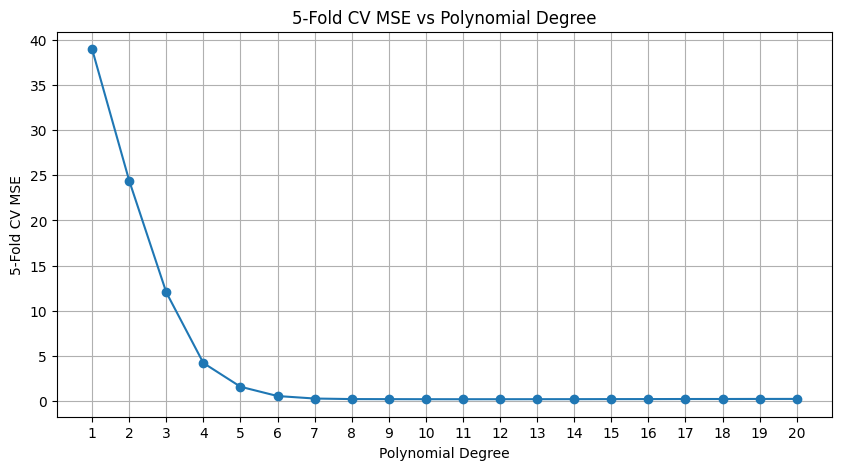

In [15]:
# Plot CV MSE
plt.figure(figsize=(10, 5))

plt.plot(
    results_df["degree"],
    results_df["cv_mse"],
    marker="o"
)

plt.xlabel("Polynomial Degree")
plt.ylabel("5-Fold CV MSE")
plt.title("5-Fold CV MSE vs Polynomial Degree")
plt.xticks(range(1, 21))
plt.grid(True)

plt.show()

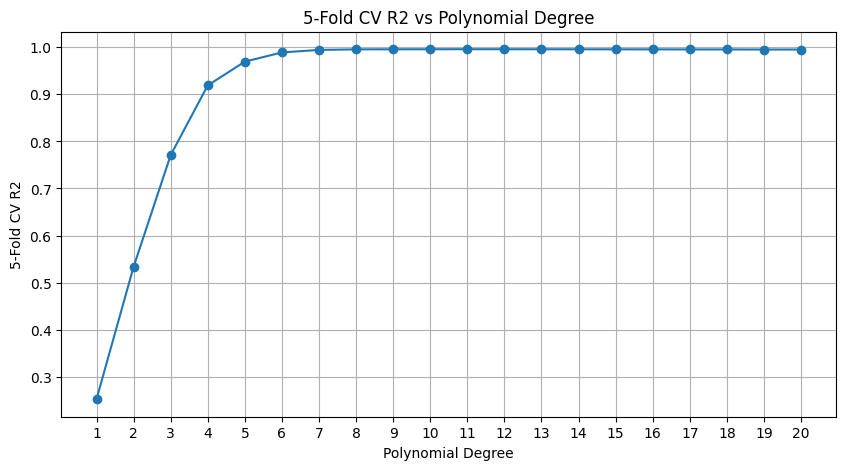

In [16]:
# Plot CV R2
plt.figure(figsize=(10, 5))

plt.plot(
    results_df["degree"],
    results_df["cv_r2"],
    marker="o"
)

plt.xlabel("Polynomial Degree")
plt.ylabel("5-Fold CV R2")
plt.title("5-Fold CV R2 vs Polynomial Degree")
plt.xticks(range(1, 21))
plt.grid(True)

plt.show()

In [17]:
# Display all degree-alpha combinations
alpha_results_df = alpha_results_df.sort_values(
    ["degree", "cv_mse"]
)

display(alpha_results_df)

,degree,alpha,cv_mse,cv_r2
8,1,1.000000e+00,38.944579,0.252151
7,1,1.000000e-01,38.945222,0.252133
6,1,1.000000e-02,38.945296,0.252131
5,1,1.000000e-03,38.945304,0.252131
4,1,1.000000e-04,38.945305,0.252131
...,...,...,...,...
194,20,1.000000e-04,2.043697,0.961235
193,20,1.000000e-05,5.736079,0.890030
192,20,1.000000e-06,16.606158,0.672247
191,20,1.000000e-07,74.469078,-0.451386


In [18]:
# Select the best degree and alpha
best_row = results_df.loc[
    results_df["cv_mse"].idxmin()
]

best_degree = int(best_row["degree"])
best_alpha = float(best_row["best_alpha"])
best_cv_mse = float(best_row["cv_mse"])
best_cv_r2 = float(best_row["cv_r2"])

print("Best Polynomial Degree:", best_degree)
print("Best Alpha:", best_alpha)
print("Best CV MSE:", best_cv_mse)
print("Best CV R2:", best_cv_r2)

Best Polynomial Degree: 11
Best Alpha: 0.1
Best CV MSE: 0.21363110665148452
Best CV R2: 0.995872971922737


In [19]:
# Generate polynomial features using the selected degree
X_poly = make_polynomial_features(
    X,
    best_degree
)

X_test_poly = make_polynomial_features(
    X_test,
    best_degree
)

print("Final polynomial training shape:", X_poly.shape)
print("Final polynomial test shape:", X_test_poly.shape)

# Train final Ridge model on all training data
final_weights = calculate_ridge_weights(
    X_poly,
    y,
    best_alpha
)

# Training predictions
y_train_pred = predict(
    X_poly,
    final_weights
)

# Training metrics
train_mse = calculate_mse(
    y,
    y_train_pred
)

train_r2 = calculate_r2(
    y,
    y_train_pred
)

print("Final Training MSE:", train_mse)
print("Final Training R2:", train_r2)

Final polynomial training shape: (1000, 363)
Final polynomial test shape: (1000, 363)
Final Training MSE: 0.15004215171958835
Final Training R2: 0.9971213873053693


In [20]:
# Predict test data
y_test_pred = predict(
    X_test_poly,
    final_weights
)

# Create submission file
submission = pd.DataFrame({
    "y": y_test_pred
})

submission.to_csv(
    "/content/BT2024087_predictions_var2.csv",
    index=False
)

print("Predictions generated:", len(y_test_pred))
print("Prediction file saved as:")
print("BT2024087_predictions_var2.csv")

display(submission.head(10))

Predictions generated: 1000
Prediction file saved as:
BT2024087_predictions_var2.csv


,y
0,-1.792138
1,4.747273
2,0.587891
3,2.158757
4,-0.040365
5,0.605422
6,0.469025
7,7.654949
8,6.220278
9,-3.670000


In [21]:
# Combine coordinates and predictions for inspection
test_predictions = test_df.copy()
test_predictions["predicted_y"] = y_test_pred

display(test_predictions.head(20))

,x1,x2,x3,predicted_y
0,0.704191,-1.000000,0.256672,-1.792138
1,1.000000,0.210961,-0.276823,4.747273
2,-0.101679,0.450327,0.765422,0.587891
3,-0.011956,-1.000000,-0.239959,2.158757
4,-0.200880,-0.331336,0.763863,-0.040365
5,-0.710966,-0.447304,0.406589,0.605422
6,-0.838914,-1.000000,-0.815229,0.469025
7,-0.874790,0.418625,-1.000000,7.654949
8,1.000000,-0.398485,-0.843383,6.220278
9,-1.000000,-0.058413,-0.244279,-3.670000
